In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [14]:
df = pd.read_csv("heart.csv")
x = df[["restecg", "oldpeak"]]
y = df["target"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
m1 = DecisionTreeClassifier(random_state=0)
m2 = KNeighborsClassifier()
m3 = RandomForestClassifier(random_state=0)
m4 = XGBClassifier(random_state=0)

In [15]:
# --- Hard Voting ---
hard = VotingClassifier(estimators=[('dt', m1), ('knn', m2), ('rf', m3), ('xgb', m4)], voting='hard')
hard.fit(x_train, y_train)
print("Hard Voting Accuracy:", hard.score(x_test, y_test) * 100)  # ans: hard voting accuracy

# --- Soft Voting ---
soft = VotingClassifier(estimators=[('dt', m1), ('knn', m2), ('rf', m3), ('xgb', m4)], voting='soft')
soft.fit(x_train, y_train)
print("Soft Voting Accuracy:", soft.score(x_test, y_test) * 100)  # ans: soft voting accuracy


Hard Voting Accuracy: 78.04878048780488
Soft Voting Accuracy: 77.07317073170732


In [16]:
# --- Best Weights ---
weights = [(1,1,1,1), (2,1,1,1), (1,2,2,1), (1,1,2,2), (3,1,2,1)]
print("\nWeighted Voting Accuracies:")
for w in weights:
    wv = VotingClassifier(estimators=[('dt', m1), ('knn', m2), ('rf', m3), ('xgb', m4)], voting='soft', weights=w)
    wv.fit(x_train, y_train)
    print(f"Weights {w} -> Accuracy: {wv.score(x_test, y_test) * 100:.2f}%")  # ans: best weight accuracy



Weighted Voting Accuracies:
Weights (1, 1, 1, 1) -> Accuracy: 77.07%
Weights (2, 1, 1, 1) -> Accuracy: 76.59%
Weights (1, 2, 2, 1) -> Accuracy: 77.07%
Weights (1, 1, 2, 2) -> Accuracy: 76.59%
Weights (3, 1, 2, 1) -> Accuracy: 76.59%


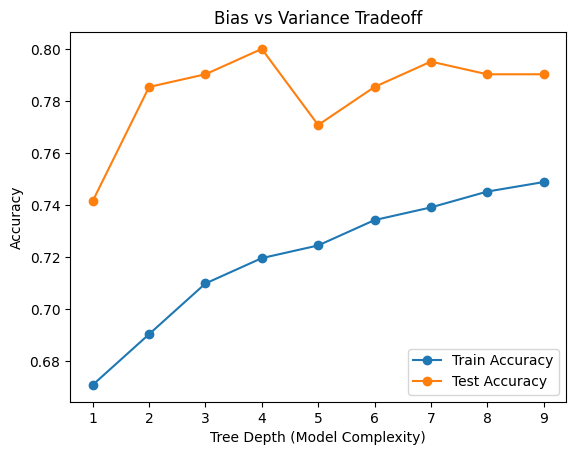

In [17]:
# Bias and Variance Tradeoff Analysis (using Decision Tree)

depths = range(1, 10)
train_scores = []
test_scores = []

for d in depths:
    dt_temp = DecisionTreeClassifier(max_depth=d, random_state=0)
    dt_temp.fit(x_train, y_train)
    train_scores.append(dt_temp.score(x_train, y_train))
    test_scores.append(dt_temp.score(x_test, y_test))

plt.plot(depths, train_scores, 'o-', label="Train Accuracy")
plt.plot(depths, test_scores, 'o-', label="Test Accuracy")
plt.xlabel("Tree Depth (Model Complexity)")
plt.ylabel("Accuracy")
plt.title("Bias vs Variance Tradeoff")
plt.legend()
plt.show()

# The plot shows how increasing model complexity (tree depth) affects bias and variance.
# For shallow trees (low depth), both train and test accuracy are low → High Bias (Underfitting)
# For deep trees, training accuracy is very high but test accuracy drops → High Variance (Overfitting)
# The best depth is where test accuracy is highest and the gap between curves is minimal → Optimal Tradeoff.